In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src import load_and_prep_data, run_validation_loop, HawkesExp

In [3]:
sequences = load_and_prep_data('data/raw/retail_data.csv')

In [4]:
factory_reg = lambda p: HawkesExp(baseline_model=p, penalty_weight=50.0)

df_results = run_validation_loop(sequences, model_factory=factory_reg, label="Regularized", min_events=20)

Running 'Regularized': N=107 users
Fitting Global Profile...


100%|██████████| 107/107 [00:00<00:00, 193.25it/s]


Hawkes Win Rate: 65.42%
Avg RMSE Improvement: -2.09%


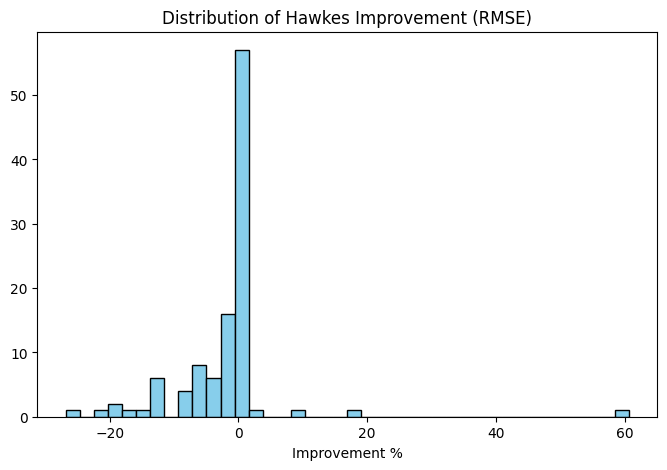

In [5]:
print(f"Hawkes Win Rate: {df_results['hawkes_win'].mean():.2%}")
print(f"Avg RMSE Improvement: {df_results['imp_rmse'].mean():.2f}%")

plt.figure(figsize=(8, 5))
plt.hist(df_results['imp_rmse'], bins=40, color='skyblue', edgecolor='black')
plt.title('Distribution of Hawkes Improvement (RMSE)')
plt.xlabel('Improvement %')
plt.show()

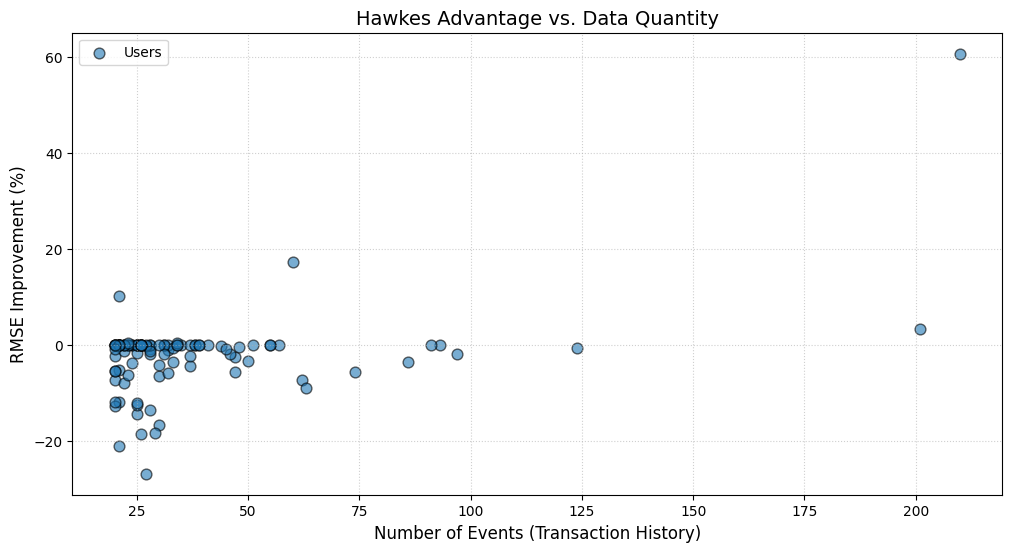

In [6]:
# Настраиваем размер
plt.figure(figsize=(12, 6))

plt.scatter(df_results['events_total'], df_results['imp_rmse'], 
            alpha=0.6, s=60, edgecolors='black', label='Users')


plt.title('Hawkes Advantage vs. Data Quantity', fontsize=14)
plt.xlabel('Number of Events (Transaction History)', fontsize=12)
plt.ylabel('RMSE Improvement (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()

Winner ID: 12748.0 (Imp: 60.7%)
Loser ID:  15498.0 (Imp: -26.9%)


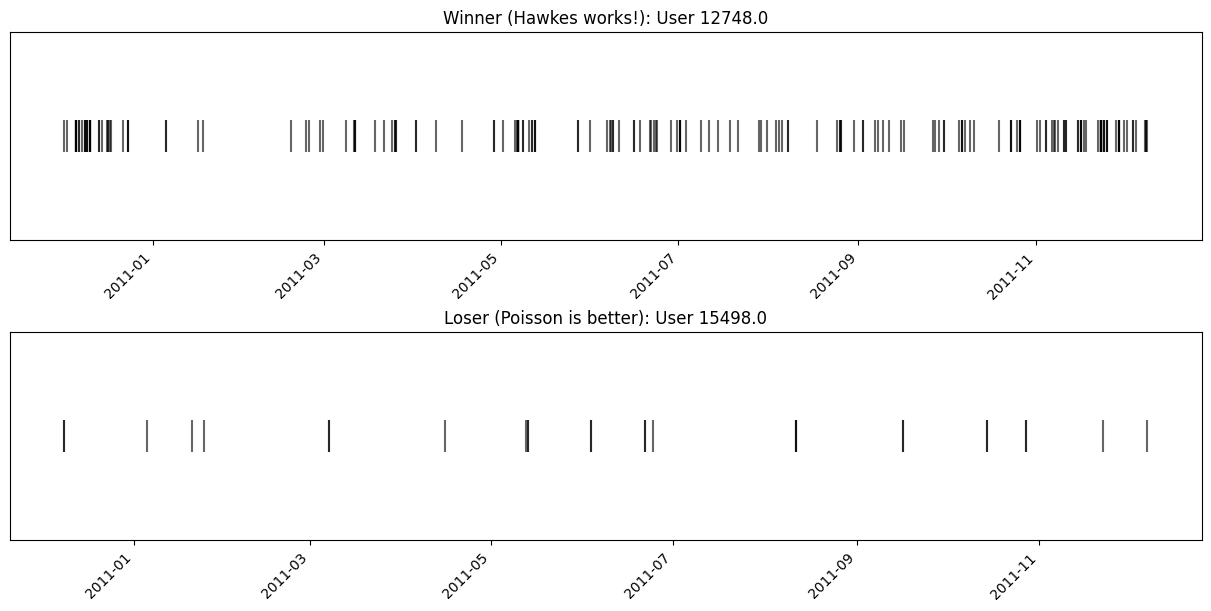

In [7]:
winners = df_results[df_results['imp_rmse'] > 10].sort_values('imp_rmse', ascending=False)
losers = df_results[df_results['imp_rmse'] < -10].sort_values('imp_rmse')

winner_id = winners.iloc[0]['user_id'] if not winners.empty else df_results.iloc[0]['user_id']
loser_id = losers.iloc[0]['user_id'] if not losers.empty else df_results.iloc[-1]['user_id']

print(f"Winner ID: {winner_id} (Imp: {winners.iloc[0]['imp_rmse']:.1f}%)")
print(f"Loser ID:  {loser_id} (Imp: {losers.iloc[0]['imp_rmse']:.1f}%)")

def plot_timeline(user_id, ax, title):
    times = sequences[user_id]
    ax.scatter(times, [1]*len(times), marker='|', s=500, alpha=0.6, color='black')
    ax.set_yticks([])
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)

plot_timeline(winner_id, ax1, f"Winner (Hawkes works!): User {winner_id}")
plot_timeline(loser_id, ax2, f"Loser (Poisson is better): User {loser_id}")

plt.show()

<>:44: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:44: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/h8/sn554hy55hl3fv0bp7zkdmq80000gn/T/ipykernel_24036/3890643470.py:44: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.ylabel('Intensity $\lambda(t)$')
/var/folders/h8/sn554hy55hl3fv0bp7zkdmq80000gn/T/ipykernel_24036/3890643470.py:23: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  t_grid = pd.date_range(start=t_start, end=t_end, freq='1H')


User 15498.0
Alpha (Excitation): 0.3153
Beta (Decay):       1.5462
Ratio (Alpha/Beta): 0.2039 (Branching factor)


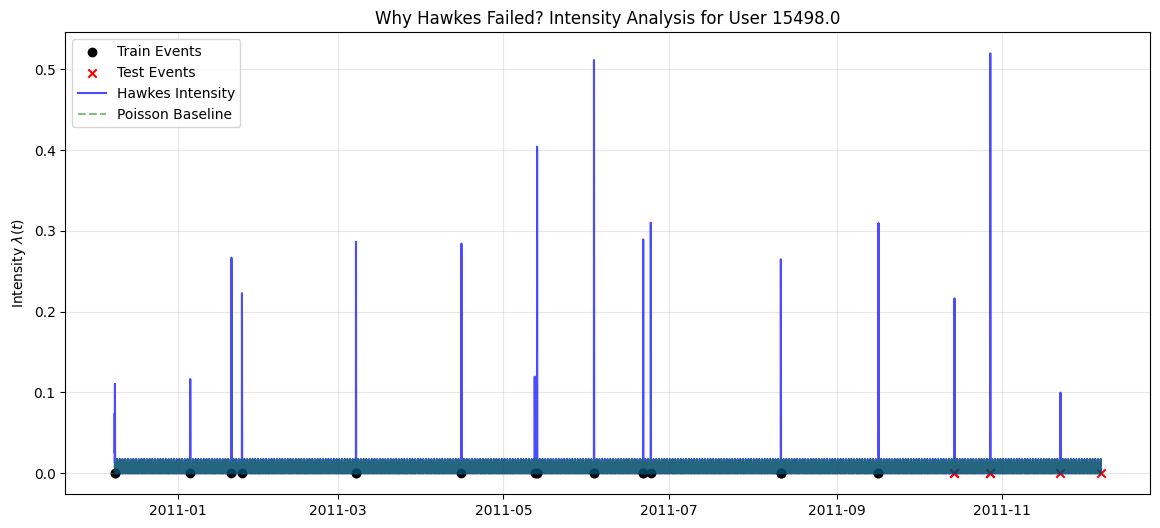

In [8]:
from src import temporal_train_test_split, SeasonalPoisson, HawkesExp

target_uid = loser_id 

times = sequences[target_uid]
train, test = temporal_train_test_split(times, 0.8)

poisson = SeasonalPoisson().fit(train)
hawkes = HawkesExp(baseline_model=poisson).fit(train)

print(f"User {target_uid}")
print(f"Alpha (Excitation): {hawkes.params[0]:.4f}")
print(f"Beta (Decay):       {hawkes.params[1]:.4f}")
print(f"Ratio (Alpha/Beta): {hawkes.params[0]/hawkes.params[1]:.4f} (Branching factor)")

plt.figure(figsize=(14, 6))

plt.scatter(train, [0]*len(train), marker='o', color='black', label='Train Events')
plt.scatter(test, [0]*len(test), marker='x', color='red', label='Test Events')

t_start = train[0]
t_end = test[-1]
t_grid = pd.date_range(start=t_start, end=t_end, freq='1H')

lambda_vals = []
history = [] 
full_events = sorted(list(train) + list(test))
curr_event_idx = 0

for t in t_grid:
    while curr_event_idx < len(full_events) and full_events[curr_event_idx] <= t:
        history.append(full_events[curr_event_idx])
        curr_event_idx += 1
    
    lam = hawkes.get_intensity(t, history)
    lambda_vals.append(lam)

plt.plot(t_grid, lambda_vals, color='blue', alpha=0.7, label='Hawkes Intensity')

poisson_level = [poisson.get_intensity(t) for t in t_grid]
plt.plot(t_grid, poisson_level, color='green', linestyle='--', alpha=0.5, label='Poisson Baseline')

plt.title(f'Why Hawkes Failed? Intensity Analysis for User {target_uid}')
plt.ylabel('Intensity $\lambda(t)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

            alpha        beta  branching_ratio
count  107.000000  107.000000     1.070000e+02
mean     0.058898    2.590073     2.587567e-02
std      0.074882    1.481674     3.871688e-02
min      0.000001    0.228931     4.180886e-07
25%      0.000001    1.432580     1.000050e-06
50%      0.022824    1.983223     1.033368e-02
75%      0.099905    3.961466     3.934875e-02
max      0.324233    5.000000     2.087582e-01


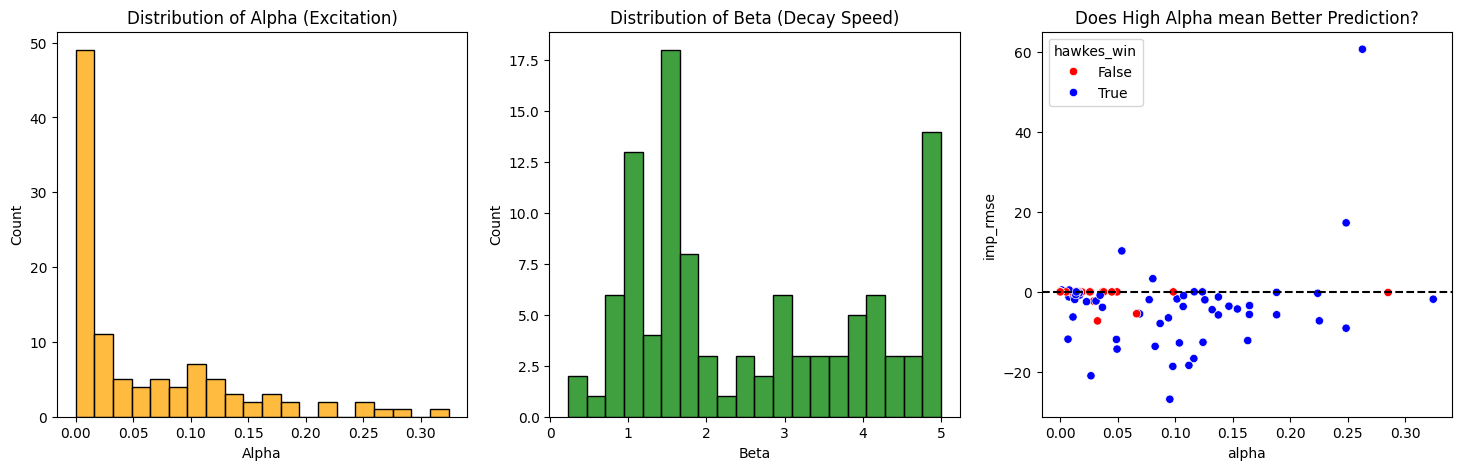

In [9]:
import seaborn as sns
print(df_results[['alpha', 'beta', 'branching_ratio']].describe())

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_results['alpha'], bins=20, ax=ax[0], color='orange')
ax[0].set_title('Distribution of Alpha (Excitation)')
ax[0].set_xlabel('Alpha')

sns.histplot(df_results['beta'], bins=20, ax=ax[1], color='green')
ax[1].set_title('Distribution of Beta (Decay Speed)')
ax[1].set_xlabel('Beta')

sns.scatterplot(data=df_results, x='alpha', y='imp_rmse', hue='hawkes_win', ax=ax[2], palette={True: 'blue', False: 'red'})
ax[2].set_title('Does High Alpha mean Better Prediction?')
ax[2].axhline(0, color='black', linestyle='--')

plt.show()

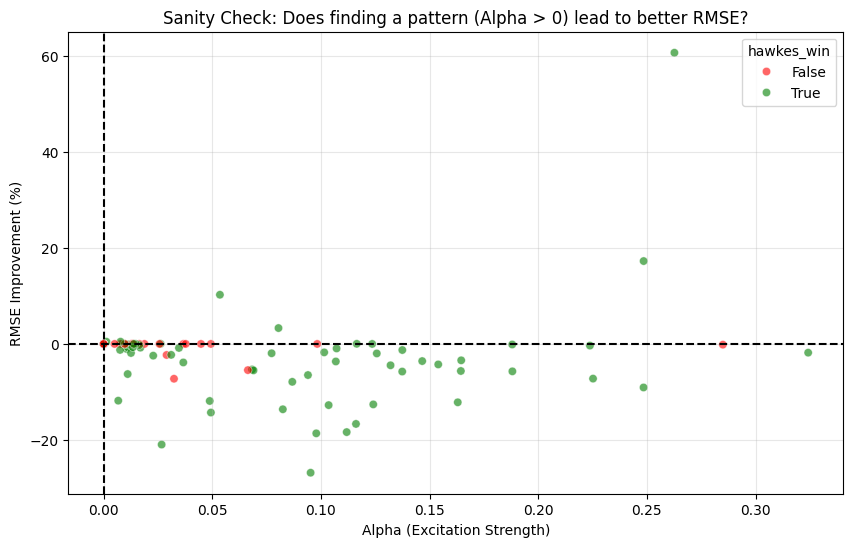

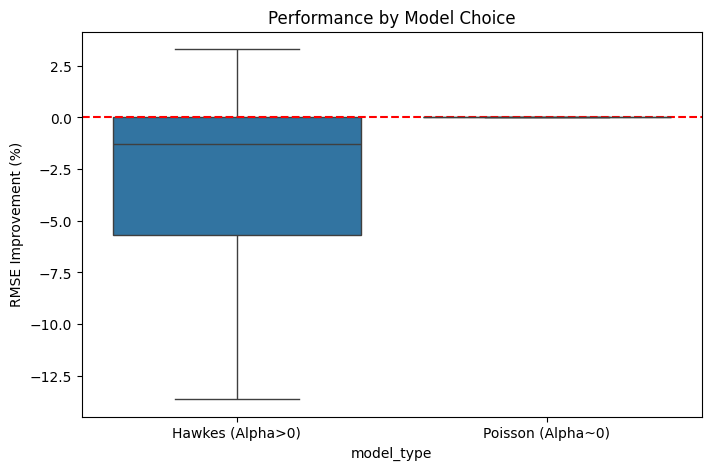

Statictics:
                   count      mean       std        min       25%       50%  \
model_type                                                                    
Hawkes (Alpha>0)    78.0 -2.872411  9.785714 -26.852037 -5.697625 -1.261429   
Poisson (Alpha~0)   29.0  0.000087  0.000830  -0.001295  0.000000  0.000000   

                   75%        max  
model_type                         
Hawkes (Alpha>0)   0.0  60.707359  
Poisson (Alpha~0)  0.0   0.004121  


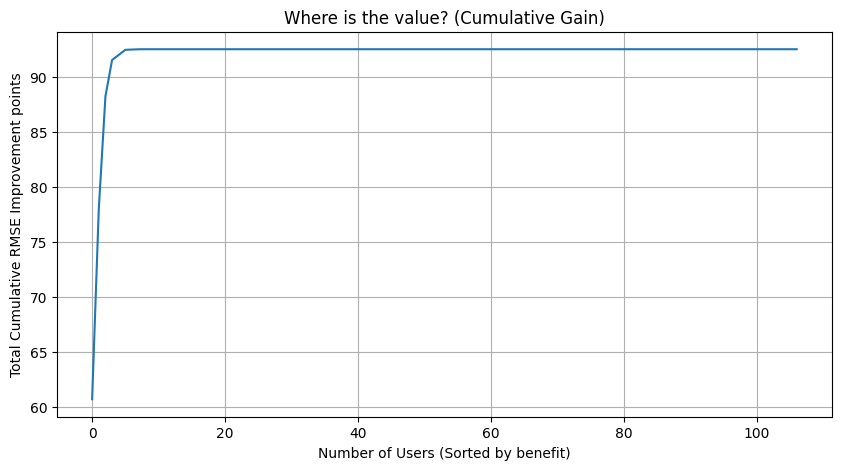


Users with > 5% improvement: 3 out of 107 (2.8%)


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Предполагаем, что df_reg - это результат твоего эксперимента с регуляризацией
df = df_results.copy()

# 1. SCATTER PLOT: Alpha vs Improvement (Самый важный график)
# Если модель работает правильно, точки должны лежать на диагонали или в правом верхнем углу.
# Если у нас Alpha большая, а Improvement отрицательный (внизу справа) -> Переобучение.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='alpha', y='imp_rmse', hue='hawkes_win', 
                palette={True: 'green', False: 'red'}, alpha=0.6)
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')
plt.title('Sanity Check: Does finding a pattern (Alpha > 0) lead to better RMSE?')
plt.xlabel('Alpha (Excitation Strength)')
plt.ylabel('RMSE Improvement (%)')
plt.grid(True, alpha=0.3)
plt.show()

# 2. BOXPLOT: Разделяем "Молчунов" и "Активных"
# L1 регуляризация должна была занулить многих. Проверим это.
# Считаем Alpha=0, если она меньше 0.001
df['model_type'] = df['alpha'].apply(lambda x: 'Poisson (Alpha~0)' if x < 0.001 else 'Hawkes (Alpha>0)')

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='model_type', y='imp_rmse', showfliers=False) # showfliers=False уберет дикие выбросы для наглядности
plt.axhline(0, color='red', linestyle='--')
plt.title('Performance by Model Choice')
plt.ylabel('RMSE Improvement (%)')
plt.show()

print("Statictics:")
print(df.groupby('model_type')['imp_rmse'].describe())

# 3. CUMULATIVE GAIN (Где деньги?)
# Отсортируем юзеров по выигрышу и посмотрим, сколько % юзеров дают 80% пользы.
df_sorted = df.sort_values('imp_rmse', ascending=False).reset_index(drop=True)
df_sorted['cumulative_imp'] = df_sorted['imp_rmse'].clip(lower=0).cumsum() # Считаем только положительный эффект

plt.figure(figsize=(10, 5))
plt.plot(df_sorted.index, df_sorted['cumulative_imp'])
plt.xlabel('Number of Users (Sorted by benefit)')
plt.ylabel('Total Cumulative RMSE Improvement points')
plt.title('Where is the value? (Cumulative Gain)')
plt.grid(True)
plt.show()

# Сколько юзеров реально полезны?
n_useful = len(df[df['imp_rmse'] > 5.0]) # Улучшение больше 5%
print(f"\nUsers with > 5% improvement: {n_useful} out of {len(df)} ({n_useful/len(df):.1%})")